# Ejercicio de **Clasificación Binaria**

Los modelos de clasificacion son modelos que buscan predecir si una observacion pertenece a un determinado grupo o a otro en funcion de sus características.

# Importamos las librerí­as

In [81]:
import numpy as np
import pandas as pd
import os

## Para regresión logística

In [82]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

## Para normalizar los datos

Documentación: https://scikit-learn.org/stable/modules/preprocessing.html

In [83]:
from sklearn import preprocessing

## Clasificador KNN

In [84]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn import metrics

## Naive Bayes (con cross-validation)

In [85]:
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

## Árboles de decisión

In [86]:
from sklearn import tree
from sklearn.tree import export_graphviz
from six import StringIO
import pydotplus
import graphviz

## Random Forest

In [87]:
from sklearn.ensemble import RandomForestClassifier

## XGBoost

In [88]:
import xgboost as xgb

## Gráficas personalizadas

In [89]:
import matplotlib.pyplot as plt
import seaborn as sns

def cuadro_matriz_confusion(confusion):
    fig, ax = plt.subplots()

    labels = ['Verdadero Neg', 'Falso Pos', 'Falso Neg', 'Verdadero Pos']
    categories = ['0', '1']
    counts = ['{0:,}'.format(value) for value in confusion.flatten()]
    percentages = ['{0:.2%}'.format(value) for value in confusion.flatten() / np.sum(confusion)]
    labels = [f'{label}\n{count}\n{percentage}' for label, count, percentage in zip(labels, counts, percentages)]
    labels = np.asarray(labels).reshape(2, 2)

    sns.heatmap(confusion, annot=labels, fmt='', cmap='Blues', xticklabels=categories, yticklabels=categories, ax=ax)
    plt.xlabel('Valores predichos')
    plt.ylabel('Valores reales')
    plt.title('Matriz de confusión')
    plt.show()

## Métricas personalizadas

In [90]:
def resumen_metricas(confusion, y_test):
    # Calcular las tasas de precisión, sensibilidad, especificidad y valor predictivo positivo
    accuracy = (confusion[0, 0] + confusion[1, 1]) / len(y_test)
    recall = confusion[1, 1] / (confusion[1, 1] + confusion[1, 0])
    specificity = confusion[0, 0] / (confusion[0, 0] + confusion[0, 1])
    ppv = confusion[1, 1] / (confusion[1, 1] + confusion[0, 1])

    # Mostrar las tasas de precisión, sensibilidad, especificidad y valor predictivo positivo
    print("Precisión (Accuracy):", accuracy)
    print("Sensibilidad (Recall):", recall)
    print("Especificidad:", specificity)
    print("Valor Predictivo Positivo (PPV):", ppv)

# Carga de los datos:

In [91]:
data = pd.read_csv("/content/sample_data/heart_data.csv")

Para aplicar los modelos es necesario que todos los valores tengan un formato numérico
Para ello hacemos las siguientes transformaciones.

El primer paso es conocer nuestros datos.
Realizamos una primera visualizacion.

## Exploración y Análisis de los datos

In [92]:
data.head(n=10)

,index,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
5,5,8,21914,1,151,67.0,120,80,2,2,0,0,0,0
6,6,9,22113,1,157,93.0,130,80,3,1,0,0,1,0
7,7,12,22584,2,178,95.0,130,90,3,3,0,0,1,1
8,8,13,17668,1,158,71.0,110,70,1,1,0,0,1,0
9,9,14,19834,1,164,68.0,110,60,1,1,0,0,0,0


In [93]:
# Realizamos un resumen estadistico de las variables.
descripcion_data = data.describe(include="all").T
descripcion_data

,count,mean,std,min,25%,50%,75%,max
index,70000.0,34999.500000,20207.403759,0.0,17499.75,34999.5,52499.25,69999.0
id,70000.0,49972.419900,28851.302323,0.0,25006.75,50001.5,74889.25,99999.0
age,70000.0,19468.865814,2467.251667,10798.0,17664.00,19703.0,21327.00,23713.0
gender,70000.0,1.349571,0.476838,1.0,1.00,1.0,2.00,2.0
height,70000.0,164.359229,8.210126,55.0,159.00,165.0,170.00,250.0
weight,70000.0,74.205690,14.395757,10.0,65.00,72.0,82.00,200.0
ap_hi,70000.0,128.817286,154.011419,-150.0,120.00,120.0,140.00,16020.0
ap_lo,70000.0,96.630414,188.472530,-70.0,80.00,80.0,90.00,11000.0
cholesterol,70000.0,1.366871,0.680250,1.0,1.00,1.0,2.00,3.0
gluc,70000.0,1.226457,0.572270,1.0,1.00,1.0,1.00,3.0


In [94]:
# Comprobamos que no hay valores perdidos.
data.isnull().sum()

,0
index,0
id,0
age,0
gender,0
height,0
weight,0
ap_hi,0
ap_lo,0
cholesterol,0
gluc,0


In [95]:
# Con esta funcion vemos si existen (TRUE) o no (FALSE) datos perdidos
data.isnull().any().any()

np.False_

## Balanceo de la columna objetivo

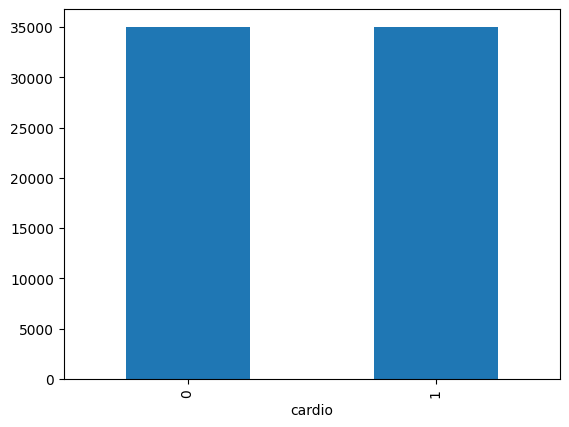

In [96]:
data["cardio"].value_counts().plot(kind = "bar");

In [97]:
# Tras comprobar que no existen valores perdidos analizamos las variables.
# El objetivo es determinar si todas las variables son utiles para la modelizacion.
# Hay una serie de variables que no nos proporcionan informacion.
# Eliminamos esas variables
del data['index']
del data['id']

In [98]:
# La variable "gender" toma valores 1 y 2. La reducimos en una unidad para que tome 0 y 1
data["gender"] = data["gender"] - 1

In [99]:
# Volvemos a visualizar los datos.
data.head(n=10)

,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,18393,1,168,62.0,110,80,1,1,0,0,1,0
1,20228,0,156,85.0,140,90,3,1,0,0,1,1
2,18857,0,165,64.0,130,70,3,1,0,0,0,1
3,17623,1,169,82.0,150,100,1,1,0,0,1,1
4,17474,0,156,56.0,100,60,1,1,0,0,0,0
5,21914,0,151,67.0,120,80,2,2,0,0,0,0
6,22113,0,157,93.0,130,80,3,1,0,0,1,0
7,22584,1,178,95.0,130,90,3,3,0,0,1,1
8,17668,0,158,71.0,110,70,1,1,0,0,1,0
9,19834,0,164,68.0,110,60,1,1,0,0,0,0


Vemos los valores únicos de las columnas categóricas (Las que tienen menos de, por ejemplo, 15 valores únicos)

In [100]:
for columna in data.columns:
    if len(data[columna].unique()) < 15:
        print(f"Columna {columna} -> Valores únicos {data[columna].unique()}")

Columna gender -> Valores únicos [1 0]
Columna cholesterol -> Valores únicos [1 3 2]
Columna gluc -> Valores únicos [1 2 3]
Columna smoke -> Valores únicos [0 1]
Columna alco -> Valores únicos [0 1]
Columna active -> Valores únicos [1 0]
Columna cardio -> Valores únicos [0 1]


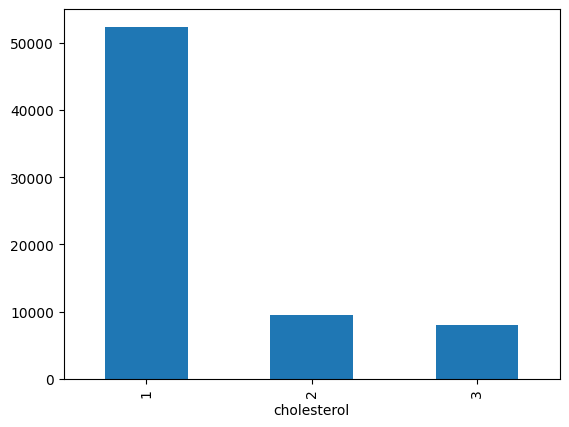

In [101]:
data['cholesterol'].value_counts().plot(kind = "bar");
# Cambio posible
# data['cholesterol'] = data['cholesterol'] != 1

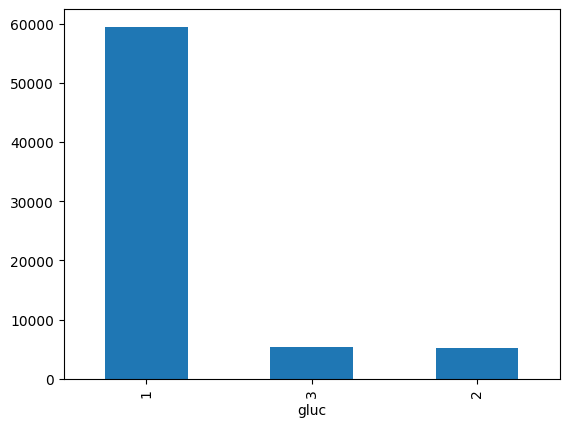

In [102]:
data['gluc'].value_counts().plot(kind = "bar");
# Cambio posible
# data['gluc'] = data['gluc'] != 1

Posteriormente podemos considerar la opción de dumificar o no las columnas `cholesterol`y `gluc`

Ya no hacemos más limpieza en este caso. En este punto lo consideramos "datosfinal"

In [103]:
datos_final = data

## Outliers

### Presión alta

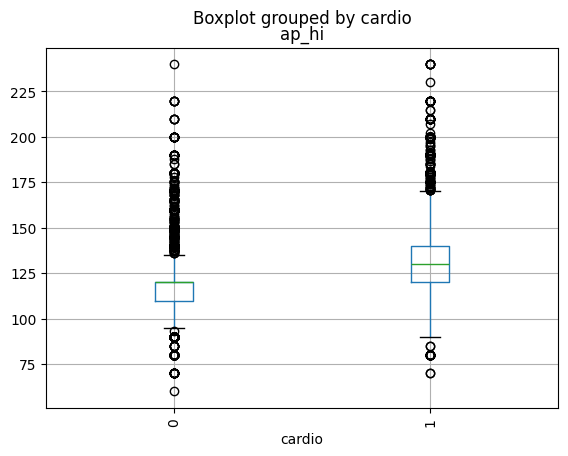

In [104]:
data = data[(data["ap_hi"]<300) & (data["ap_hi"]>50)]
data.boxplot(column="ap_hi", by="cardio", ax=None, fontsize=None, rot=90, grid=True);


### Presión baja

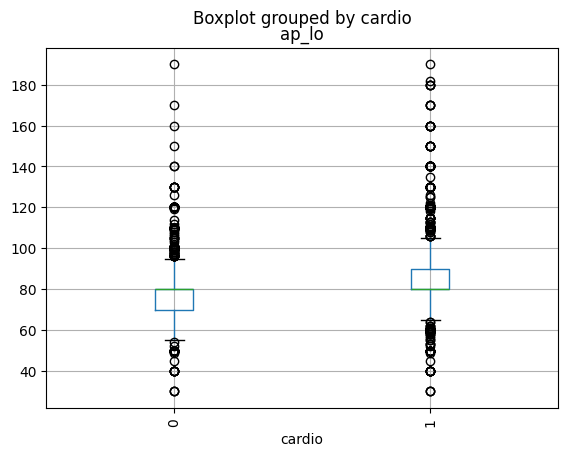

In [105]:
data = data[(data["ap_lo"]<250) & (data["ap_lo"]>25)]
data.boxplot(column="ap_lo", by="cardio", ax=None, fontsize=None, rot=90, grid=True);

In [106]:
data['ap_lo'].value_counts().head(20)

,count
ap_lo,
80,34736
90,14269
70,10218
100,4077
60,2716
110,398
79,357
85,290
75,210


<Axes: title={'center': 'Distribucion de la Tensión arterial'}, ylabel='Density'>

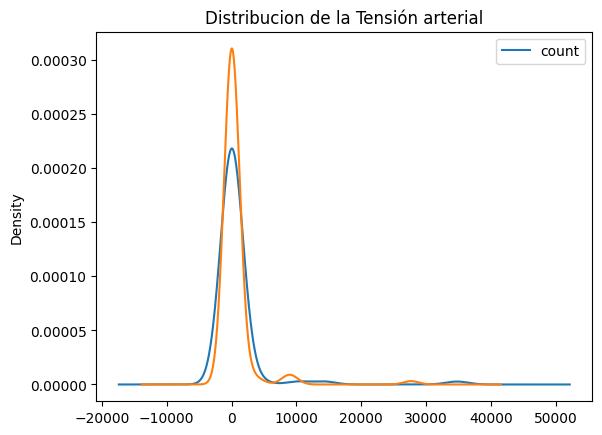

In [107]:
data['ap_lo'].value_counts().sort_index().plot(x='Presión arterial baja',y='frecuencia',
                                           kind='kde', legend=True,title='Distribucion de la Tensión arterial')
data['ap_hi'].value_counts().sort_index().plot(x='Presión arterial alta',y='frecuencia',
                                           kind='kde')

### Alturas Anómalas

Vemos que las personas con altura menor de 125cm tienen pesos exagerados para esa altura. Probablemente se trate de errores en los datos.

In [108]:
data.loc[data["height"]<125, ["height", "weight"]]

,height,weight
224,76,55.0
3420,100,70.0
3735,120,70.0
3752,120,30.0
4212,120,80.0
...,...,...
65302,99,60.0
66023,120,80.0
66479,110,90.0
66643,57,61.0


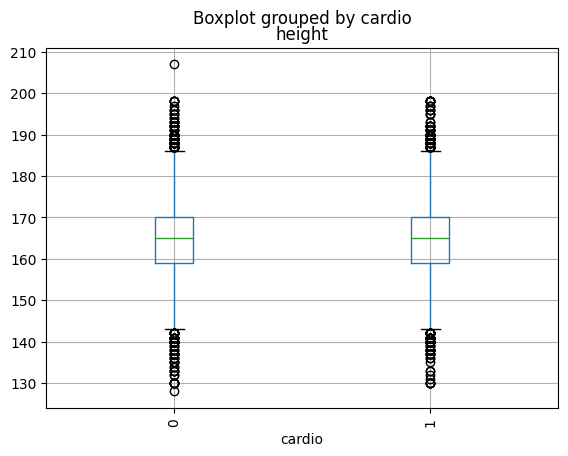

In [109]:
data = data[(data["height"]<220) & (data["height"]>125)]
data.boxplot(column="height", by="cardio", ax=None, fontsize=None, rot=90, grid=True);

### Body Mass Index anómalos

In [110]:
data["BMI"] = (10000 * data["weight"]) / (data["height"] **2)

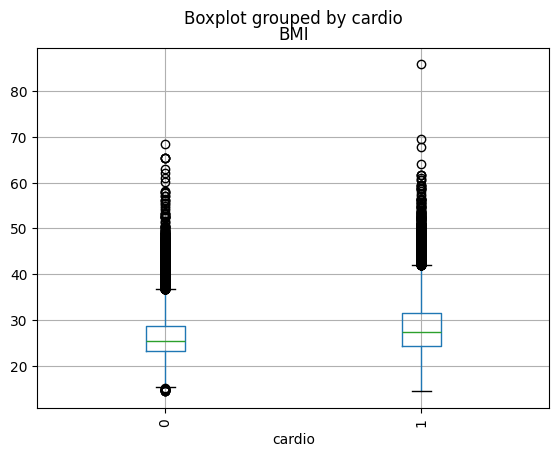

In [111]:
#data = data[data["BMI"]<90]
data = data[data["BMI"]>14]
data.boxplot(column="BMI", by="cardio", ax=None, fontsize=None, rot=90, grid=True);

In [112]:
max(data['BMI'])

85.77974319356386

Text(0, 0.5, 'Frecuencia')

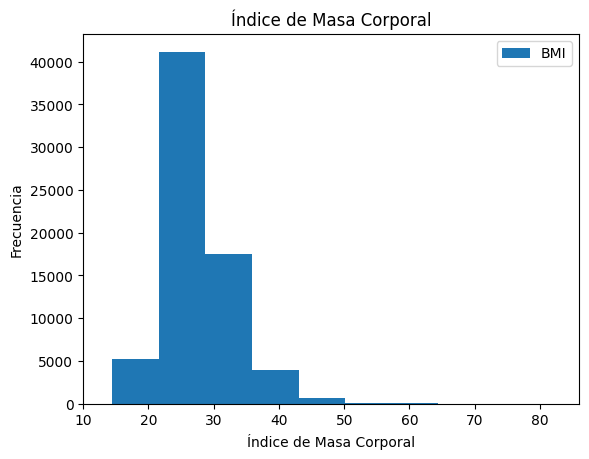

In [113]:
data['BMI'].plot(kind='hist', legend=True, title='Índice de Masa Corporal')

# Ajusta los límites del eje X
plt.xlim(10, 86)

# Configura etiquetas y muestra el gráfico
plt.xlabel('Índice de Masa Corporal')
plt.ylabel('Frecuencia')

In [114]:
data.loc[data["weight"]<40, ["height", "weight", "age", "BMI"]]

,height,weight,age,BMI
5794,151,37.00,17663,16.227358
10447,162,38.00,22007,14.479500
10627,153,37.00,21669,15.805887
11876,157,39.00,17512,15.822143
14722,143,34.00,22663,16.626730
19582,152,38.00,21334,16.447368
22016,146,32.00,15359,15.012197
25198,149,35.45,18768,15.967749
29333,153,37.00,21728,15.805887
31420,140,39.00,20575,19.897959


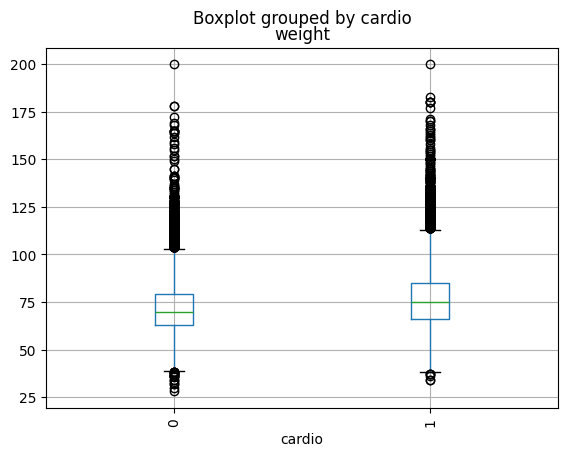

In [115]:
data.boxplot(column="weight", by="cardio", ax=None, fontsize=None, rot=90, grid=True);


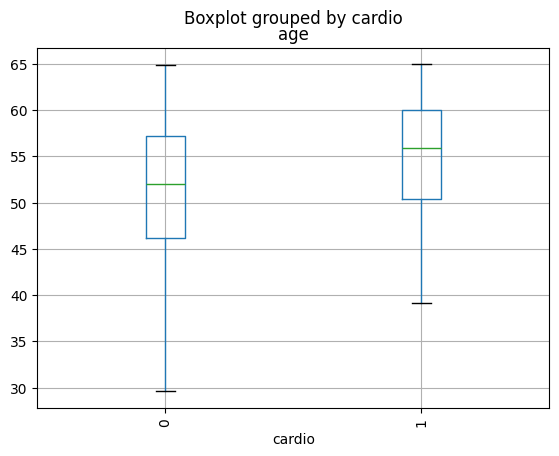

In [116]:
data2 = data
data2["age"] = data2["age"]/365
data2.boxplot(column="age", by="cardio", ax=None, fontsize=None, rot=90, grid=True);

In [117]:
datos_final = data

In [118]:
datos_final = datos_final.reset_index()
datos_final.index

RangeIndex(start=0, stop=68682, step=1)

# Correlación

In [119]:
datos_final.columns

Index(['index', 'age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio', 'BMI'],
      dtype='object')

In [120]:
datos_final = datos_final.drop(columns='index')
datos_final = datos_final.drop(columns='weight')
datos_final = datos_final.drop(columns='height')
datos_final = datos_final.drop(columns='ap_lo')

<Axes: >

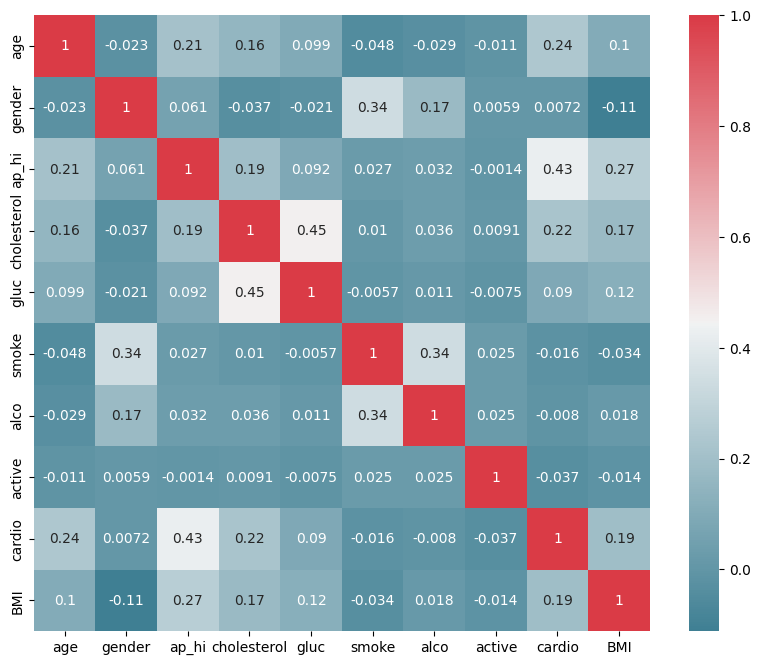

In [121]:
f, ax = plt.subplots(figsize=(10, 8))
corr = datos_final.corr()
sns.heatmap(corr, annot=True, mask=np.zeros_like(corr, dtype=bool), cmap=sns.diverging_palette(220, 10, as_cmap=True),square=True, ax=ax)

## Separación Train - Test

Vamos a preparar los datos para entrenar y evaluar los modelos utilizando la biblioteca scikit-learn (sklearn) en Python.

Aquí es lo que está haciendo cada línea:

La función `train_test_split` se utiliza para dividir los datos en conjuntos de entrenamiento y prueba de manera aleatoria.

Podría ser que las condiciones de medida de los registros de mi dataset fueran distintos en la parte baja de la tabla a las condiciones en la parte alta.

Por ello es conveniente "barajar" aleatoriamente las filas.

`random_state=42`: establece una semilla aleatoria para garantizar la reproducibilidad de la división de los datos

In [122]:
from sklearn.model_selection import train_test_split
y = datos_final['cardio']
X = datos_final.drop('cardio', axis = 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [123]:
X_train.head()

,age,gender,ap_hi,cholesterol,gluc,smoke,alco,active,BMI
20479,50.216438,0,120,1,1,0,0,1,23.437500
3406,62.515068,1,120,1,1,0,0,1,24.221453
45110,56.317808,0,120,2,1,0,0,0,22.206331
20118,54.106849,0,140,1,1,0,0,1,27.829314
56162,62.391781,1,150,1,1,0,0,1,28.081633


#   Regresión Logística

El primer modelo de calsificacion es la regresion logistica. Este modelo es una regresion que mide la probabilidad de que una observacion tome el valor 0 o 1. (Verdadero o falso, acierto o error...)

# K Nearest Neighbours

# Naïve Bayes

# Árbol de decisión

# XGBoost